In [47]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt


In [48]:
file = pd.read_excel(r"C:\Users\mistr\Downloads\PGCB_date_power_demand.xlsx")
file.shape
file.columns
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal           

In [49]:
file.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [50]:
file['datetime'] = pd.to_datetime(file['datetime'])
print(file['datetime'].head())

0   2015-04-19 22:00:00
1   2015-04-19 21:00:00
2   2015-04-19 19:00:00
3   2015-04-19 18:30:00
4   2015-04-19 18:00:00
Name: datetime, dtype: datetime64[ns]


In [51]:
file['datetime'].describe()

count                            92650
mean     2020-05-17 03:52:07.609282304
min                2015-04-19 00:00:00
25%                2017-10-31 06:15:00
50%                2020-05-21 15:30:00
75%                2022-12-03 18:22:30
max                2025-06-17 12:00:00
Name: datetime, dtype: object

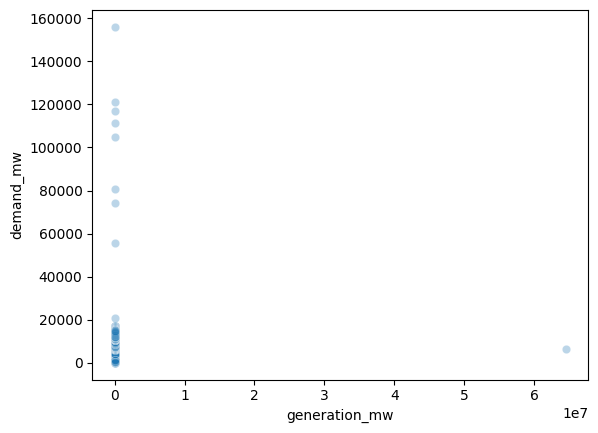

In [52]:
sns.scatterplot(x= 'generation_mw' , y ='demand_mw' , data = file , alpha = 0.3)
plt.show()

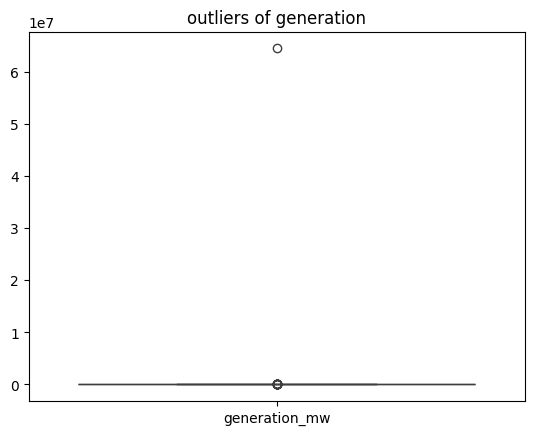

In [53]:
sns.boxplot(data=file[['generation_mw']])
plt.title('outliers of generation')
plt.show()

from boxplot we can state outlier present in generation data

In [54]:
file['generation_mw'].describe()

count    9.265000e+04
mean     9.429376e+03
std      2.119759e+05
min      7.300000e+01
25%      6.814775e+03
50%      8.412000e+03
75%      1.055600e+04
max      6.452650e+07
Name: generation_mw, dtype: float64

In [55]:
file[file['generation_mw'] > 20000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
70563,2023-01-15 04:00:00,64526500.0,6452,0,4490,265,952,30,0.0,NaN,645,82,NaN,NaN,NaN


only one outler having extreme high value 
but according to calculation of source generation of energy  the respective row it is a misprint of generation_mw 
actual geenration value upon counting - 6464

In [56]:
file.loc[70563 , 'generation_mw'] = 6464

In [57]:
file[file['generation_mw'] > 20000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks


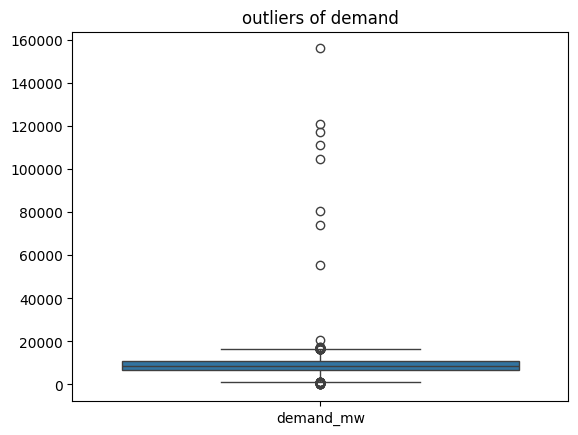

In [58]:
sns.boxplot(data=file[['demand_mw']])
plt.title('outliers of demand')
plt.show()

In [59]:
file['demand_mw'].describe()

count     92650.000000
mean       8819.646044
std        2772.150108
min           6.000000
25%        6812.250000
50%        8422.000000
75%       10633.000000
max      156050.000000
Name: demand_mw, dtype: float64

In [60]:
file[file['demand_mw'] > 20000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
18997,2017-05-17 12:00:00,7423.0,74223,60120,4232,2331,161,97,NaN,NaN,505,100,NaN,NaN,NaN
21510,2017-08-26 15:00:00,8068.0,80689,65359,4535,2617,138,170,NaN,NaN,494,120,NaN,NaN,NaN
33392,2018-12-18 08:00:00,5563.9,55639,45068,4487,333,149,65,5.9,NaN,530,76,NaN,NaN,NaN
71222,2023-02-11 18:30:00,10052.0,104860,400,4369,3211,1594,30,0.0,NaN,726,136,NaN,NaN,NaN
72872,2023-04-18 18:30:00,15172.0,156050,456,6423,5541,2197,25,0.0,NaN,944,136,NaN,NaN,NaN
77107,2023-10-04 09:00:00,10587.0,20587,0,5234,867,3221,156,88.0,4.0,901,166,NaN,NaN,NaN
77286,2023-10-11 03:00:00,11468.0,117000,222,6021,1225,2965,200,0.0,0.0,913,144,NaN,NaN,NaN
81981,2024-04-16 07:00:00,11701.0,121000,381,6742,736,2979,30,190.0,0.0,926,98,NaN,NaN,NaN
83933,2024-07-03 05:00:00,11080.0,111140,57,5265,90,3774,155,12.0,1.0,913,60,NaN,NaN,NaN


In [61]:
demand_index = file.columns.get_loc('demand_mw')
print(demand_index )
remark_index = file.columns.get_loc('remarks')
columns_after_demand = file.columns[demand_index+1 : remark_index]
print(list(file.columns[demand_index+1:remark_index]))
file['total_energy_generation'] = file[columns_after_demand].sum(axis=1)
print(file['total_energy_generation'])

2
['load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal']
0            0.0
1            0.0
2         6897.0
3         6933.0
4         6874.0
          ...   
92645    12698.0
92646    13280.0
92647    13719.0
92648    14114.0
92649    14649.0
Name: total_energy_generation, Length: 92650, dtype: float64


In [62]:
file.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,0.0
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,0.0
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,6897.0
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,6933.0
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,6874.0


KeyboardInterrupt: 

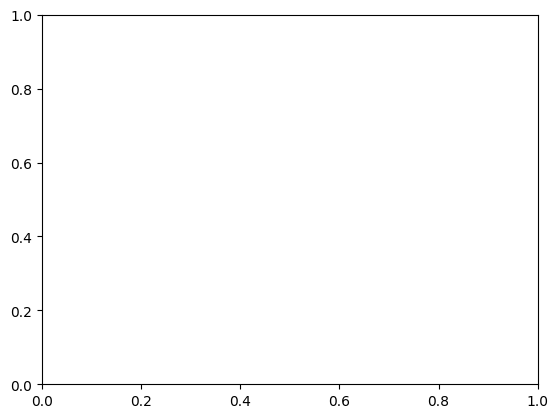

In [63]:
sns.lineplot(x= 'generation_mw' , y = 'total_energy_generation',data = file)
plt.show()

In [64]:
file[file['demand_mw'] > 20000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
18997,2017-05-17 12:00:00,7423.0,74223,60120,4232,2331,161,97,NaN,NaN,505,100,NaN,NaN,NaN,67546.0
21510,2017-08-26 15:00:00,8068.0,80689,65359,4535,2617,138,170,NaN,NaN,494,120,NaN,NaN,NaN,73433.0
33392,2018-12-18 08:00:00,5563.9,55639,45068,4487,333,149,65,5.9,NaN,530,76,NaN,NaN,NaN,50713.9
71222,2023-02-11 18:30:00,10052.0,104860,400,4369,3211,1594,30,0.0,NaN,726,136,NaN,NaN,NaN,10466.0
72872,2023-04-18 18:30:00,15172.0,156050,456,6423,5541,2197,25,0.0,NaN,944,136,NaN,NaN,NaN,15722.0
77107,2023-10-04 09:00:00,10587.0,20587,0,5234,867,3221,156,88.0,4.0,901,166,NaN,NaN,NaN,10637.0
77286,2023-10-11 03:00:00,11468.0,117000,222,6021,1225,2965,200,0.0,0.0,913,144,NaN,NaN,NaN,11690.0
81981,2024-04-16 07:00:00,11701.0,121000,381,6742,736,2979,30,190.0,0.0,926,98,NaN,NaN,NaN,12082.0
83933,2024-07-03 05:00:00,11080.0,111140,57,5265,90,3774,155,12.0,1.0,913,60,NaN,NaN,NaN,10327.0


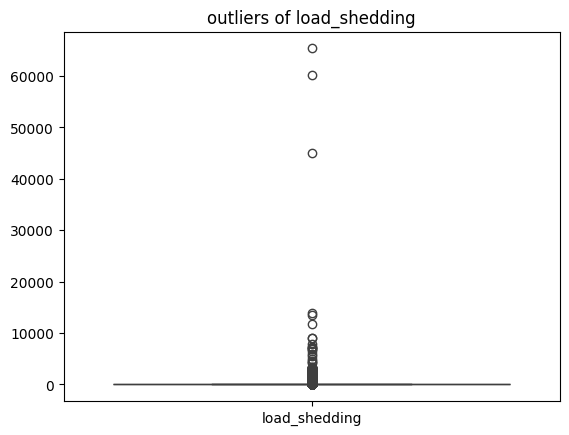

In [65]:
sns.boxplot(data=file[['load_shedding']])
plt.title('outliers of load_shedding')
plt.show()

In [66]:
file[file['load_shedding'] > 20000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
18997,2017-05-17 12:00:00,7423.0,74223,60120,4232,2331,161,97,NaN,NaN,505,100,NaN,NaN,NaN,67546.0
21510,2017-08-26 15:00:00,8068.0,80689,65359,4535,2617,138,170,NaN,NaN,494,120,NaN,NaN,NaN,73433.0
33392,2018-12-18 08:00:00,5563.9,55639,45068,4487,333,149,65,5.9,NaN,530,76,NaN,NaN,NaN,50713.9


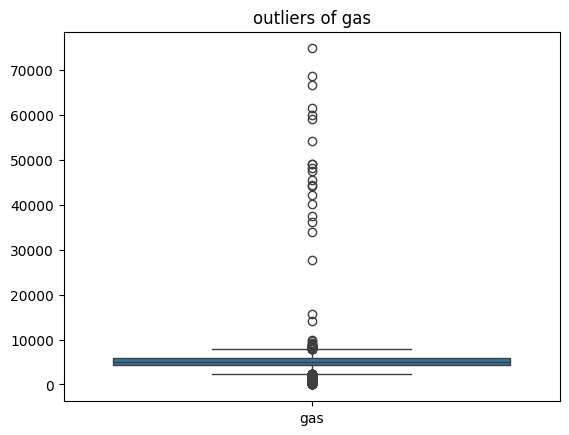

In [67]:
sns.boxplot(data=file[['gas']])
plt.title('outliers of gas')
plt.show()

In [68]:
file[file['gas'] > 20000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
1260,2015-06-09 21:00:00,7704.0,7704,0,44442,2559,182,77,NaN,NaN,444,0,NaN,NaN,NaN,47704.0
4279,2015-10-01 02:00:00,6614.0,6614,0,44158,1600,169,239,NaN,NaN,448,0,NaN,NaN,NaN,46614.0
7295,2016-01-25 17:00:00,6581.0,6581,0,33861,2120,86,76,NaN,NaN,438,0,NaN,NaN,NaN,36581.0
8804,2016-03-22 02:00:00,6271.0,6271,0,40179,1443,169,81,NaN,NaN,459,40,NaN,NaN,NaN,42371.0
11515,2016-07-04 18:30:00,7312.0,7312,0,48312,1718,171,40,NaN,NaN,469,88,NaN,NaN,NaN,50798.0
11581,2016-07-06 08:00:00,4358.0,4358,0,36136,174,171,132,NaN,NaN,221,48,NaN,NaN,NaN,36882.0
22796,2017-10-16 07:00:00,7196.8,7197,0,74818,1562,74,169,0.8,NaN,481,78,NaN,NaN,NaN,77182.8
23993,2017-12-04 20:00:00,7359.0,7359,0,49121,1681,73,105,0.0,NaN,482,116,NaN,NaN,NaN,51578.0
25367,2018-01-30 01:00:00,5165.0,5165,0,42225,274,362,28,0.0,NaN,200,78,NaN,NaN,NaN,43167.0
29356,2018-07-09 03:00:00,9161.0,9161,0,54112,2845,149,164,0.0,NaN,472,124,NaN,NaN,NaN,57866.0


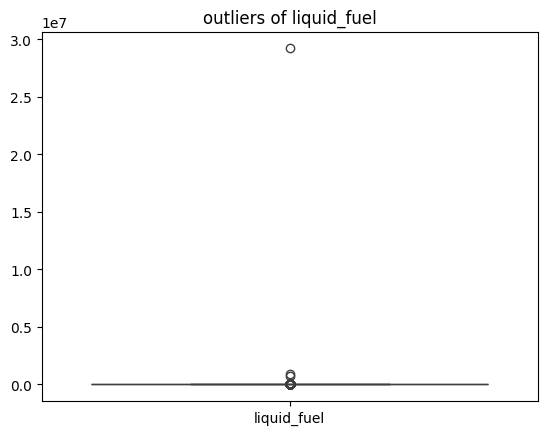

In [69]:
sns.boxplot(data=file[['liquid_fuel']])
plt.title('outliers of liquid_fuel')
plt.show()

In [70]:
file[file['liquid_fuel'] > 10000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
1977,2015-07-06 15:00:00,6951.0,6951,0,4909,13936,156,42,NaN,NaN,451,0,NaN,NaN,NaN,19494.0
3821,2015-09-14 10:00:00,6758.0,6758,0,4382,41512,178,234,NaN,NaN,452,0,NaN,NaN,Day_Peak,46758.0
10542,2016-05-28 19:00:00,7873.0,7873,0,4652,42435,170,78,NaN,NaN,459,84,NaN,NaN,NaN,47878.0
14417,2016-10-24 22:00:00,7551.0,7551,0,5077,15464,166,160,NaN,NaN,508,80,NaN,NaN,NaN,21455.0
16990,2017-02-25 23:00:00,6025.0,6025,0,4563,698113,80,497,NaN,NaN,540,80,NaN,NaN,NaN,703873.0
17974,2017-04-05 01:00:00,6308.0,6308,0,4575,893165,120,62,NaN,NaN,499,62,NaN,NaN,NaN,898483.0
19370,2017-06-01 02:00:00,7945.0,7945,0,5310,18902,73,73,NaN,NaN,500,136,NaN,NaN,NaN,24994.0
25728,2018-02-14 17:00:00,7083.0,7083,0,4212,12827,365,77,0.0,NaN,481,126,NaN,NaN,NaN,18088.0
28565,2018-06-08 18:00:00,9464.0,9464,0,5485,29223,322,117,0.0,NaN,458,170,NaN,NaN,NaN,35775.0
38392,2019-07-07 14:00:00,9545.1,9545,0,5934,24958,199,79,0.3,NaN,697,148,NaN,NaN,NaN,32015.3


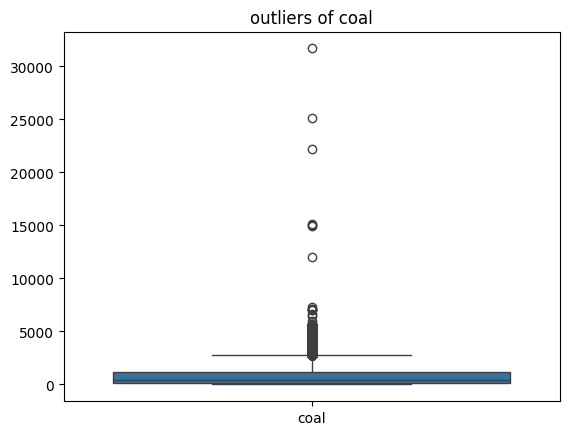

In [71]:
sns.boxplot(data=file[['coal']])
plt.title('outliers of coal')
plt.show()

In [72]:
file[file['coal'] > 10000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
34195,2019-01-19 05:00:00,5052.0,5052,0,4425,114,14940,0,0.0,NaN,256,70,NaN,NaN,NaN,19805.0
66832,2022-08-19 08:00:00,10452.0,10600,136,5851,2187,11991,116,110.0,NaN,924,90,NaN,NaN,NaN,21405.0
71226,2023-02-11 15:00:00,8353.0,9113,700,4177,1490,15121,30,122.0,NaN,917,110,NaN,NaN,NaN,22667.0
72537,2023-04-04 05:00:00,8871.0,8871,0,5099,734,25085,0,1.0,NaN,863,106,NaN,NaN,NaN,31888.0
72849,2023-04-17 18:00:00,14577.0,15400,758,6088,5222,22206,25,0.0,NaN,943,146,NaN,NaN,NaN,35388.0
74539,2023-06-23 03:00:00,11018.0,12500,1415,6760,1611,15010,60,0.0,1.0,930,164,NaN,NaN,NaN,25951.0
83761,2024-06-26 02:00:00,12677.0,14900,2123,5510,2837,31687,149,0.0,1.0,920,92,NaN,NaN,NaN,43319.0


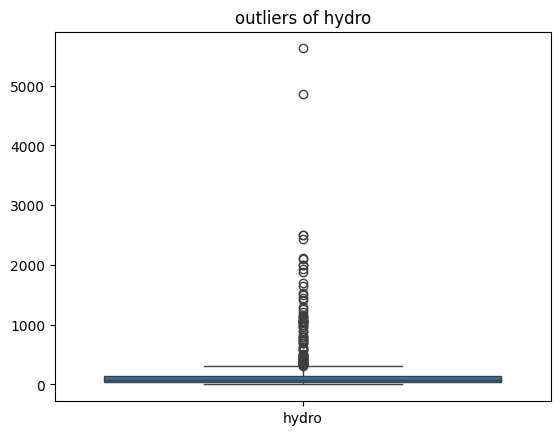

In [73]:
sns.boxplot(data=file[['hydro']])
plt.title('outliers of hydro')
plt.show()

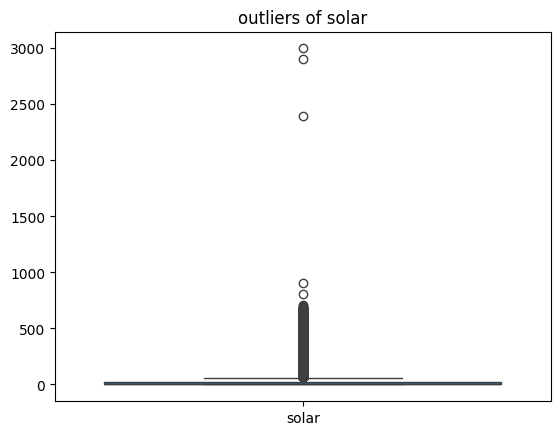

In [74]:
sns.boxplot(data=file[['solar']])
plt.title('outliers of solar')
plt.show()

In [75]:
file[file['solar'] > 1500]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
39750,2019-08-30 09:00:00,8824.1,8824,0,6416,919,220,215,2901.0,NaN,909,128,NaN,NaN,NaN,11708.0
74533,2023-06-23 09:00:00,10878.0,11350,451,6489,1521,1507,60,2398.0,11.0,930,142,NaN,NaN,NaN,13509.0
80379,2024-02-12 09:00:00,9571.0,9655,80,4000,1075,3418,46,2998.0,0.0,624,110,NaN,NaN,NaN,12351.0


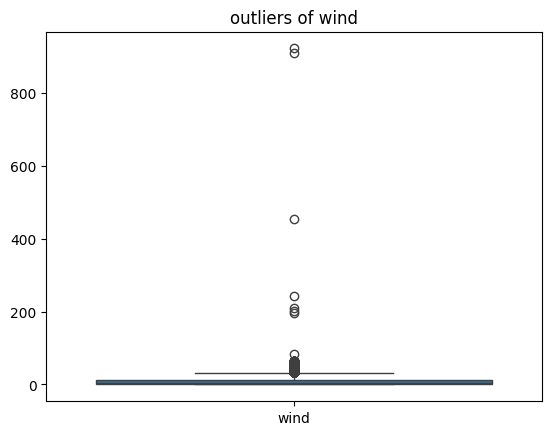

In [76]:
sns.boxplot(data=file[['wind']])
plt.title('outliers of wind')
plt.show()

In [77]:
file[file['wind'] > 200]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
76718,2023-09-19 22:00:00,13140.0,13400,248,6369,1622,4018,201,0.0,201.0,767,138,NaN,NaN,NaN,13564.0
77329,2023-10-13 10:00:00,10162.0,10162,0,5636,675,2438,2438,153.0,243.0,913,104,NaN,NaN,NaN,12600.0
81425,2024-03-25 12:00:00,11529.0,11529,0,5420,770,3784,30,0.0,454.0,923,148,NaN,NaN,NaN,11529.0
83510,2024-06-16 03:00:00,11867.0,11867,0,5906,850,4103,0,15.0,922.0,1000,122,NaN,NaN,NaN,12918.0
85594,2024-09-08 17:00:00,12517.0,14100,1512,4597,2291,3406,211,3.0,211.0,873,70,1025.0,NaN,NaN,14199.0
87374,2024-11-18 13:00:00,9649.0,9649,0,4891,804,1776,93,413.0,910.0,910,54,708.0,0.0,NaN,10559.0


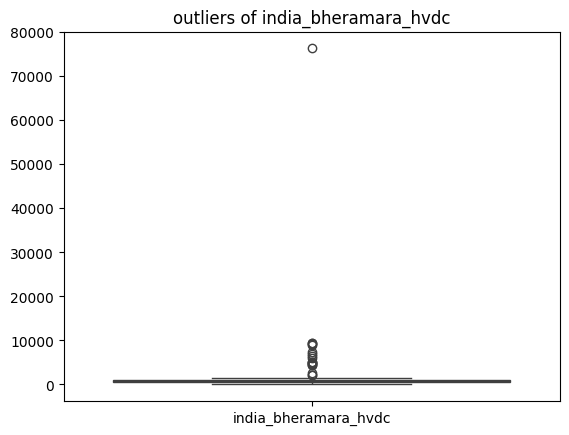

In [78]:
sns.boxplot(data=file[['india_bheramara_hvdc']])
plt.title('outliers of india_bheramara_hvdc')
plt.show()

In [79]:
file[file['india_bheramara_hvdc'] > 10000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
35302,2019-03-05 22:00:00,6923.0,6923,0,5564,314,149,42,0.0,NaN,76292,92,NaN,NaN,NaN,82453.0


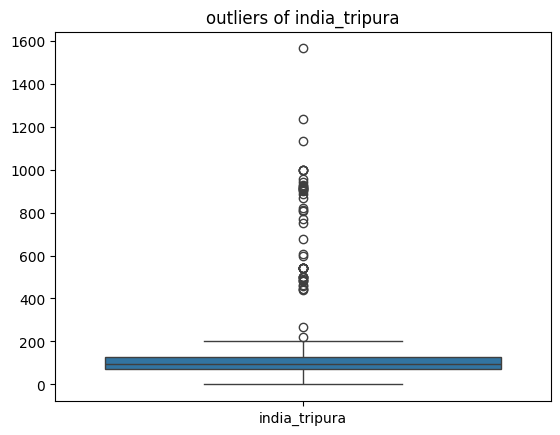

In [80]:
sns.boxplot(data=file[['india_tripura']])
plt.title('outliers of india_tripura')
plt.show()

In [81]:
file[file['india_tripura'] > 800]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
35694,2019-03-21 18:00:00,10451.0,10451,0,5916,3127,214,73,0.0,NaN,964,955,NaN,NaN,NaN,11249.0
36931,2019-05-09 02:00:00,11042.0,11042,0,6410,3228,264,40,0.0,NaN,953,942,NaN,NaN,NaN,11837.0
38697,2019-07-19 10:00:00,8195.0,8195,0,5958,802,175,116,24.0,NaN,916,904,NaN,NaN,NaN,8895.0
39216,2019-08-09 00:00:00,9764.0,9764,0,6408,1804,355,211,0.0,NaN,162,900,NaN,NaN,NaN,9840.0
40705,2019-10-08 23:00:00,9257.0,9257,0,6497,1330,280,131,0.0,NaN,926,915,NaN,NaN,NaN,10079.0
46447,2020-05-26 11:00:00,5863.0,5863,0,4500,150,149,34,17.0,NaN,945,869,NaN,NaN,Day_Peak,6664.0
48552,2020-08-18 06:00:00,8492.7,8493,0,5310,1409,599,154,1.7,NaN,929,1000,NaN,NaN,NaN,9402.7
49715,2020-10-04 18:00:00,12317.0,12317,0,5966,4532,720,42,0.0,NaN,911,1565,NaN,NaN,Evening_Peak,13736.0
56725,2021-07-11 06:00:00,9827.0,9827,0,6912,1327,600,53,11.0,NaN,820,806,NaN,NaN,NaN,10529.0
56926,2021-07-19 05:00:00,9820.0,9820,0,6723,1371,682,122,1.0,NaN,823,812,NaN,NaN,NaN,10534.0


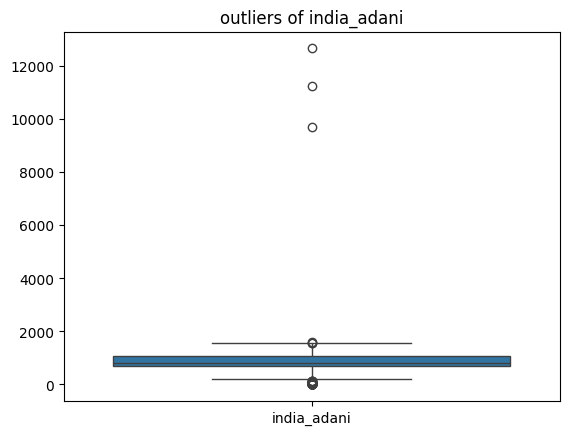

In [82]:
sns.boxplot(data=file[['india_adani']])
plt.title('outliers of india_adani')
plt.show()

In [83]:
file[file['india_adani'] > 2000]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
89171,2025-01-29 15:00:00,9709.0,9780,68,4275,342,3353,40,142.0,7.0,923,60,9709.0,0.0,NaN,18919.0
91353,2025-04-26 08:00:00,12665.0,12850,177,5929,1070,3096,40,355.0,22.0,865,32,12665.0,0.0,NaN,24251.0
91464,2025-05-01 21:00:00,11241.0,11241,0,6675,172,2585,40,0.0,0.0,914,30,11241.0,0.0,NaN,21657.0


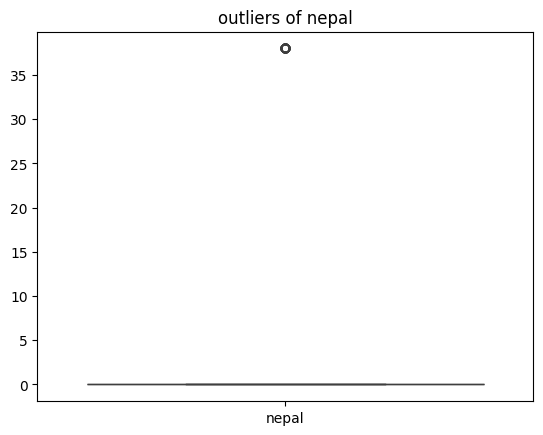

In [84]:
sns.boxplot(data=file[['nepal']])
plt.title('outliers of nepal')
plt.show()

In [85]:
file[file['nepal'] > 35]

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks,total_energy_generation
87269,2024-11-14 18:00:00,11705.0,11705,0,5081,2692,2040,134,0.0,10.0,914,68,766.0,38.0,NaN,11743.0
87288,2024-11-15 23:00:00,9121.0,9121,0,5291,287,1676,96,0.0,25.0,908,54,746.0,38.0,NaN,9121.0
87289,2024-11-15 22:00:00,9392.0,9392,0,5258,323,1941,96,0.0,19.0,908,56,753.0,38.0,NaN,9392.0
87290,2024-11-15 21:00:00,9671.0,9671,0,5170,583,2051,96,0.0,12.0,908,60,753.0,38.0,NaN,9671.0
87291,2024-11-15 20:00:00,9892.0,9892,0,5220,745,2053,96,0.0,14.0,909,56,761.0,38.0,NaN,9892.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,12698.0
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,13280.0
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,13719.0
92648,2025-06-17 01:00:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN,14114.0


In [ ]:
file['datetime'].diff().value_counts() 

### observation of energy file 
Outliers present in every column and time interval is irregular






## analysis of weather file


In [ ]:
file = pd.read_excel(r"C:\Users\mistr\Downloads\weather_data.xlsx")
file.head()

,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,23.7961,90.3805,9,21600,Asia/Dhaka,GMT+6,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
3,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
4,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0


In [ ]:
file = pd.read_excel(r'C:\Users\mistr\Downloads\weather_data.xlsx',skiprows = 3)
file.head()

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [ ]:
file.columns

Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)',
       'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)',
       'cloud_cover (%)', 'sunshine_duration (s)'],
      dtype='object')

In [ ]:
file.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107304 entries, 0 to 107303
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   time                            107304 non-null  datetime64[ns]
 1   temperature_2m (°C)             107304 non-null  float64       
 2   relative_humidity_2m (%)        107304 non-null  int64         
 3   apparent_temperature (°C)       107304 non-null  float64       
 4   precipitation (mm)              107304 non-null  float64       
 5   dew_point_2m (°C)               107304 non-null  float64       
 6   soil_temperature_0_to_7cm (°C)  107304 non-null  float64       
 7   wind_direction_10m (°)          107304 non-null  int64         
 8   cloud_cover (%)                 107304 non-null  int64         
 9   sunshine_duration (s)           107304 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage:

In [ ]:
file.isnull().sum()

time                              0
temperature_2m (°C)               0
relative_humidity_2m (%)          0
apparent_temperature (°C)         0
precipitation (mm)                0
dew_point_2m (°C)                 0
soil_temperature_0_to_7cm (°C)    0
wind_direction_10m (°)            0
cloud_cover (%)                   0
sunshine_duration (s)             0
dtype: int64

In [ ]:
file['apparent_temperature (°C)'].describe()

count    107304.000000
mean         28.804437
std           6.905288
min           6.600000
25%          24.200000
50%          30.800000
75%          33.700000
max          45.600000
Name: apparent_temperature (°C), dtype: float64

In [ ]:
file['apparent_temperature (°C)'].describe()

count    107304.000000
mean         28.804437
std           6.905288
min           6.600000
25%          24.200000
50%          30.800000
75%          33.700000
max          45.600000
Name: apparent_temperature (°C), dtype: float64

In [ ]:
file['precipitation (mm)'].describe()

count    107304.000000
mean          0.205420
std           0.895574
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          43.800000
Name: precipitation (mm), dtype: float64

In [ ]:
file['sunshine_duration (s)'].describe()

count    107304.000000
mean       1386.484587
std        1704.209881
min           0.000000
25%           0.000000
50%           0.000000
75%        3600.000000
max        3600.000000
Name: sunshine_duration (s), dtype: float64

In [ ]:
file['wind_direction_10m (°)'].describe()

count    107304.000000
mean        195.691260
std          94.451905
min           1.000000
25%         136.000000
50%         180.000000
75%         286.000000
max         360.000000
Name: wind_direction_10m (°), dtype: float64

In [ ]:
print(file['soil_temperature_0_to_7cm (°C)'].isna().sum())
file['soil_temperature_0_to_7cm (°C)'].describe()

0


count    107304.000000
mean         26.769709
std           4.908599
min          11.700000
25%          23.800000
50%          27.600000
75%          29.900000
max          44.500000
Name: soil_temperature_0_to_7cm (°C), dtype: float64

In [ ]:
print(file['dew_point_2m (°C)'].isna().sum())
file['dew_point_2m (°C)'].describe()


0


count    107304.000000
mean         20.633153
std           5.231144
min           2.500000
25%          15.800000
50%          22.800000
75%          25.200000
max          28.600000
Name: dew_point_2m (°C), dtype: float64

### Observation of Weather file
upon observing .describe() of all cols of weather file we can see there is not any outliers present and no null value is present 

## Analysis of Economic file 

In [ ]:
file = pd.read_csv(r"C:\Users\mistr\Downloads\economic_full_1.csv")
file.head()

,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


In [ ]:
file.info

<bound method DataFrame.info of      Country Name                                     Indicator Name  \
0               X     Intentional homicides, male (per 100,000 male)   
1               X           Battle-related deaths (number of people)   
2               X          Voice and Accountability: Percentile Rank   
3               X  Transport services (% of commercial service ex...   
4               X  Computer, communications and other services (%...   
...           ...                                                ...   
1511            X  Net bilateral aid flows from DAC donors, Total...   
1512            X  Net bilateral aid flows from DAC donors, Portu...   
1513            X  Net bilateral aid flows from DAC donors, Nethe...   
1514            X  Net bilateral aid flows from DAC donors, Japan...   
1515            X  Net bilateral aid flows from DAC donors, Hunga...   

         Indicator Code  1960  1961  1962  1963  1964  1965  1966  ...  \
0     VC.IHR.PSRC.MA.P5   NaN

In [ ]:
file.shape

(1516, 69)

In [ ]:
file.columns

Index(['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961',
       '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970',
       '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979',
       '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988',
       '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997',
       '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')

### Observation of Econmic file 
To many indicators to for training so we can choose imp indicators for training also recent years (10-15) as economic situation is somewhat related with recent year economic condition 